<a href="https://colab.research.google.com/github/jessicasalazar/vision_computador/blob/main/Taller_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers as L

In [ ]:
# Configuración
IMG_SIZE = 160  # tamaño al que redimensionamos (rápido y válido para MobileNetV2)
BATCH    = 128
EPOCHS_FROZEN   = 6
EPOCHS_UNFROZEN = 6
LR_FROZEN   = 3e-4
LR_UNFROZEN = 1e-4  # LR menor para fine-tuning estable
SEED     = 1337
AUTOTUNE = tf.data.AUTOTUNE  # deja que tf.data ajuste paralelismo automáticamente

tf.random.set_seed(SEED)

In [ ]:
# Carga del dataset (cargamos CIFAR-10)
(x_train, _), (x_val, _) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# Preprocesamiento
def preprocess(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE))
    return x, y

def add_rotnet_label(x, _):
    k = tf.random.uniform((), 0, 4, dtype=tf.int32) # elegimos rotación aleatoria k∈{0,1,2,3}
    x = tf.image.rot90(x, k)
    y = k  # la etiqueta es el ángulo discretizado (0,1,2,3)
    return x, y

In [ ]:
# Pipelines tf.data
ds_train = tf.data.Dataset.from_tensor_slices((x_train, tf.zeros((x_train.shape[0],))))
ds_train = ds_train.shuffle(50000, seed=SEED)
ds_train = ds_train.map(preprocess, num_parallel_calls=AUTOTUNE)
ds_train = ds_train.map(add_rotnet_label, num_parallel_calls=AUTOTUNE)
ds_train = ds_train.batch(BATCH).prefetch(AUTOTUNE)

ds_val = tf.data.Dataset.from_tensor_slices((x_val, tf.zeros((x_val.shape[0],))))
ds_val = ds_val.map(preprocess, num_parallel_calls=AUTOTUNE)
ds_val = ds_val.map(add_rotnet_label, num_parallel_calls=AUTOTUNE)
ds_val = ds_val.batch(BATCH).prefetch(AUTOTUNE)

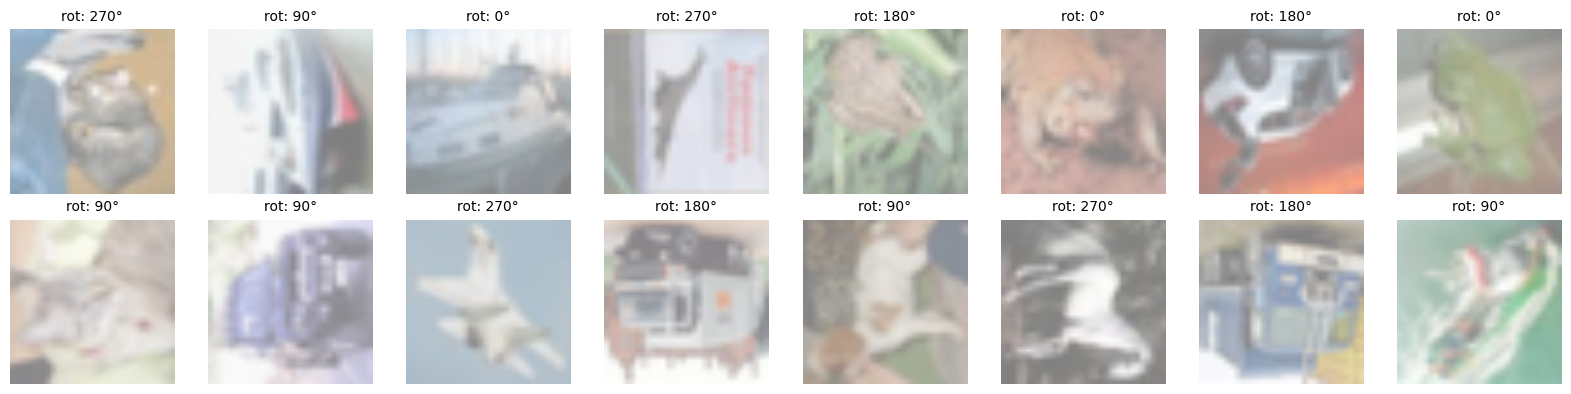

In [ ]:
# Visualizar imágenes + etiqueta de rotación
import matplotlib.pyplot as plt

N = 16
COLS = 8
DEG = ['0°','90°','180°','270°']

# Tomamos un batch del dataset de validación (también puedes usar ds_train)
for batch_imgs, batch_labels in ds_val.take(1):
    imgs = batch_imgs.numpy()
    labels = batch_labels.numpy()

    # IMPORTANTE: nuestro pipeline usa preprocess_input de MobileNetV2 → imágenes en [-1, 1].
    # Las llevamos de vuelta a [0,1] para que se vean bien.
    imgs = (imgs + 1.0) / 2.0
    imgs = imgs.clip(0, 1)

    # Armamos el grid
    rows = (N + COLS - 1) // COLS
    plt.figure(figsize=(COLS * 2, rows * 2))

    for i in range(N):
        if i >= len(imgs):
            break
        plt.subplot(rows, COLS, i + 1)
        plt.imshow(imgs[i])
        plt.title(f"rot: {DEG[int(labels[i])]}",
                  fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Modelo: MobileNetV2 (ImageNet) + cabeza RotNet
inp = L.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
base = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling='avg'
)
base.trainable = False
x = base(inp, training=False)
x = L.Dense(128, activation='relu', name='embed')(x)
x = L.Dropout(0.2)(x)
out = L.Dense(4, activation='softmax')(x)
model = tf.keras.Model(inp, out)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Compilación (fase 1: base congelada)
model.compile(optimizer=tf.keras.optimizers.Adam(LR_FROZEN),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
# Entrenamiento (fase 1)
history = model.fit(ds_train,
                    validation_data=ds_val,
                    epochs=EPOCHS_FROZEN,
                    verbose=1)

Epoch 1/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 73s 140ms/step - accuracy: 0.4339 - loss: 1.2030 - val_accuracy: 0.5387 - val_loss: 0.9663
Epoch 2/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.5388 - loss: 0.9664 - val_accuracy: 0.5674 - val_loss: 0.9126
Epoch 3/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.5625 - loss: 0.9178 - val_accuracy: 0.5699 - val_loss: 0.8933
Epoch 4/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.5758 - loss: 0.8911 - val_accuracy: 0.5834 - val_loss: 0.8662
Epoch 5/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.5848 - loss: 0.8762 - val_accuracy: 0.5874 - val_loss: 0.8648
Epoch 6/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.5964 - loss: 0.8507 - val_accuracy: 0.5916 - val_loss: 0.8491


In [ ]:
# Fine-tuning: descongelar parte final de la base
base.trainable = True
n_total = len(base.layers)
freeze_until = n_total - 40
for i, layer in enumerate(base.layers):
    layer.trainable = (i >= freeze_until)

In [ ]:
# Recompilación con LR menor
model.compile(optimizer=tf.keras.optimizers.Adam(LR_UNFROZEN),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
#  Entrenamiento (fase 2)
model.fit(ds_train,
          validation_data=ds_val,
          epochs=EPOCHS_UNFROZEN,
          verbose=1)

Epoch 1/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 70s 129ms/step - accuracy: 0.5630 - loss: 0.9445 - val_accuracy: 0.4435 - val_loss: 1.6872
Epoch 2/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.7372 - loss: 0.6261 - val_accuracy: 0.5748 - val_loss: 1.0842
Epoch 3/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.8109 - loss: 0.4840 - val_accuracy: 0.6101 - val_loss: 1.0746
Epoch 4/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.8304 - loss: 0.4293 - val_accuracy: 0.5483 - val_loss: 1.4527
Epoch 5/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.8558 - loss: 0.3769 - val_accuracy: 0.6480 - val_loss: 1.0592
Epoch 6/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.8694 - loss: 0.3454 - val_accuracy: 0.7151 - val_loss: 0.8466


In [ ]:
# ---------- Evaluación ----------
val_loss, val_acc = model.evaluate(ds_val, verbose=0)
print(f"Accuracy de rotación (val): {val_acc:.4f}")

Accuracy de rotación (val): 0.7211


In [ ]:
# Mostrar 5 pares: (fila 1) etiqueta REAL, (fila 2) etiqueta PREDICHA

import numpy as np
import matplotlib.pyplot as plt

DEG = ['0°','90°','180°','270°']
N = 5

# Tomamos un único batch del dataset de validación
for batch_imgs, batch_labels in ds_val.take(1):
    imgs_tf = batch_imgs[:N]
    labels_tf = batch_labels[:N]

    # Hacemos predicción con el modelo para esas N imágenes
    logits = model.predict(imgs_tf, verbose=0)
    preds = np.argmax(logits, axis=1)

    # Convertimos tensores a numpy para graficar y des-normalizamos de [-1,1] a [0,1]
    imgs = imgs_tf.numpy()
    imgs = (imgs + 1.0) / 2.0
    imgs = imgs.clip(0, 1)
    reals = labels_tf.numpy().astype(int)

    # Preparamos una figura con 2 filas (real/pred) y N columnas (N pares)
    plt.figure(figsize=(N * 2.2, 2 * 2.2))

    # Fila superior: REAL
    for i in range(N):
        plt.subplot(2, N, i + 1)
        plt.imshow(imgs[i])
        plt.title(f"Real: {DEG[int(reals[i])]}",
                  fontsize=10)
        plt.axis('off')

    # Fila inferior: PREDICHO
    for i in range(N):                            # recorremos de nuevo los N ejemplos
        plt.subplot(2, N, N + i + 1)              # posición (fila 2, columna i+1)
        plt.imshow(imgs[i])                       # misma imagen i
        ok = (preds[i] == reals[i])               # verificamos si acertó
        suf = "✓" if ok else "✗"                  # marca visual de acierto/error
        plt.title(f"Pred: {DEG[int(preds[i])]} {suf}", fontsize=10)  # título con predicción + marca
        plt.axis('off')                           # ocultamos ejes

    plt.tight_layout()                            # ajustamos espacios
    plt.show()                                    # mostramos la figura

    # (Opcional) Guardar la grilla en disco
    plt.savefig("rotnet_5_pares.png", dpi=150)    # guarda como PNG
    print("Guardado 'rotnet_5_pares.png'")        # confirmación
